# MODELO RNN:

In [ ]:
# Importar librerías para manipulación de datos
import pandas as pd  # Para trabajar con tablas y dataframes
import numpy as np   # Para trabajar con arrays y operaciones numéricas

# Importar librerías para visualización
import matplotlib.pyplot as plt  # Para representar gráficos

# Importar escalador robusto
from sklearn.preprocessing import RobustScaler  # Para escalar la serie con menor sensibilidad a outliers

# Importar métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error  # Para calcular MAE y RMSE

# Importar utilidades para generar combinaciones y muestrearlas aleatoriamente
from itertools import product  # Para construir todas las combinaciones posibles de la grilla
import random  # Para seleccionar una muestra aleatoria de combinaciones

# Importar TensorFlow / Keras para construir la red neuronal
import tensorflow as tf  # Framework principal de deep learning
from tensorflow.keras.models import Sequential  # Modelo secuencial de Keras
from tensorflow.keras.layers import Input, SimpleRNN, Dense, Dropout  # Capas del modelo
from tensorflow.keras.callbacks import EarlyStopping  # Callback para detener el entrenamiento si no mejora

# Fijar semillas para mejorar la reproducibilidad
np.random.seed(42)       # Semilla de NumPy
random.seed(42)          # Semilla del módulo random
tf.random.set_seed(42)   # Semilla de TensorFlow

# Configuración opcional de gráficos para que se vean mejor
plt.rcParams["figure.figsize"] = (12, 5)  # Tamaño por defecto de las figuras
plt.rcParams["axes.grid"] = True           # Activar cuadrícula por defecto

In [ ]:
# Cargar el archivo CSV con la serie agregada de Galicia
df = pd.read_csv("bbdd_biogas_galicia.csv")  # Ajusta el nombre si tu archivo se llama de otra manera

# Convertir la columna datetime al formato de fecha
df["datetime"] = pd.to_datetime(df["datetime"])  # Asegura que pandas interprete la fecha correctamente

# Ordenar las observaciones cronológicamente
df = df.sort_values("datetime")  # Muy importante en series temporales

# Resetear el índice después de ordenar
df = df.reset_index(drop=True)  # Evita mantener el índice antiguo

# Seleccionar únicamente las columnas necesarias para el modelado
df_model = df[["datetime", "generacion_biogas_mwh"]].copy()  # Copia limpia para trabajar

# Extraer la serie como array de NumPy
serie = df_model["generacion_biogas_mwh"].values  # Variable objetivo en formato array

# Mostrar información básica
print("Número total de observaciones:", len(serie))
print("Fecha inicial:", df_model["datetime"].min())
print("Fecha final:", df_model["datetime"].max())
print("\nPrimeros 5 valores de la serie:")
print(serie[:5])

Número total de observaciones: 3638
Fecha inicial: 2016-04-06 00:00:00
Fecha final: 2026-03-22 00:00:00

Primeros 5 valores de la serie:
[ 78.426  78.66   84.376 100.137  84.765]


**Divisón en conjuntos train - test**

Se divide la serie en tres subconjuntos: entrenamiento, validación y prueba. La división se realiza respetando estrictamente el orden cronológico, de manera que el modelo aprenda del pasado y se evalúe sobre observaciones futuras. Esta división permite reservar un conjunto de validación para la selección de hiperparámetros y un conjunto de prueba final para la evaluación definitiva del modelo.

In [ ]:
# Definir proporciones de la partición
train_ratio = 0.70  # Proporción destinada a entrenamiento
val_ratio = 0.15    # Proporción destinada a validación
test_ratio = 0.15   # Proporción destinada a test

# Calcular el número total de observaciones
n_total = len(serie)  # Tamaño completo de la serie

# Calcular los puntos de corte
train_end = int(n_total * train_ratio)                # Índice final del conjunto de entrenamiento
val_end = int(n_total * (train_ratio + val_ratio))    # Índice final del conjunto de validación

# Crear los subconjuntos respetando el orden temporal
train = serie[:train_end]          # Serie de entrenamiento
val = serie[train_end:val_end]     # Serie de validación
test = serie[val_end:]             # Serie de test

# Mostrar tamaños de cada subconjunto
print("Tamaño train:", len(train))
print("Tamaño validation:", len(val))
print("Tamaño test:", len(test))

Tamaño train: 2546
Tamaño validation: 546
Tamaño test: 546


**Escalado a prueba de atípicos**

 Se aplica un escalado robusto a la serie temporal. Se utiliza RobustScaler porque trabaja con la mediana y el rango intercuartílico, lo que lo hace menos sensible a los valores extremos que otros métodos de escalado más habituales. El escalador se ajusta únicamente con el conjunto de entrenamiento y después se aplica a validación y test.

In [ ]:
# Crear una instancia del escalador robusto
scaler = RobustScaler()  # Escalador menos sensible a outliers

# Ajustar el escalador solo con el conjunto de entrenamiento y transformarlo
train_scaled = scaler.fit_transform(train.reshape(-1, 1))  # Se ajusta y transforma train

# Transformar validation con el mismo escalador
val_scaled = scaler.transform(val.reshape(-1, 1))  # Solo se transforma, sin reajustar

# Transformar test con el mismo escalador
test_scaled = scaler.transform(test.reshape(-1, 1))  # Solo se transforma, sin reajustar

# Mostrar las dimensiones resultantes
print("Forma train escalado:", train_scaled.shape)
print("Forma validation escalado:", val_scaled.shape)
print("Forma test escalado:", test_scaled.shape)

Forma train escalado: (2546, 1)
Forma validation escalado: (546, 1)
Forma test escalado: (546, 1)


Se define una función que transforma la serie temporal en un problema supervisado mediante ventanas deslizantes. Para cada observación objetivo, el modelo recibe como entrada una secuencia de valores pasados y debe predecir el valor inmediatamente siguiente. Esta estructura es la que permite adaptar una serie temporal univariante a una red neuronal recurrente.

In [ ]:
# Definir una función para crear secuencias temporales
def crear_secuencias(serie_escalada, window_size):
    # Crear listas vacías para almacenar entradas y salidas
    X = []  # Secuencias de entrada
    y = []  # Valores objetivo

    # Recorrer la serie hasta el último punto posible
    for i in range(len(serie_escalada) - window_size):
        # Tomar una ventana de observaciones pasadas como entrada
        X.append(serie_escalada[i:i + window_size])

        # Tomar el valor siguiente a la ventana como objetivo
        y.append(serie_escalada[i + window_size])

    # Convertir las listas a arrays de NumPy
    X = np.array(X)
    y = np.array(y)

    # Devolver entradas y salidas
    return X, y

**Definicón de hiperparámetros**

En esta celda se define el espacio de búsqueda de hiperparámetros para la RNN. La idea no es que el modelo pruebe cualquier configuración posible, sino limitar la búsqueda a valores razonables y coherentes con el análisis exploratorio previo. Se consideran distintos tamaños de ventana, números de neuronas, tamaños de batch y niveles de dropout. Esta misma grilla base se reutilizará después en LSTM, GRU y BiLSTM para garantizar que la comparación entre arquitecturas sea homogénea y metodológicamente consistente.

In [ ]:
# Definir la grilla de hiperparámetros
param_grid = {
    "window_size": [7, 14, 21, 28],     # Ventanas basadas en la estructura semanal observada
    "units": [8, 16, 32],               # Número de neuronas en la capa recurrente
    "batch_size": [8, 16, 32],          # Tamaño del lote de entrenamiento
    "dropout": [0.0, 0.1, 0.2]          # Nivel de dropout para regularización
}

# Construir todas las combinaciones posibles de la grilla
all_combinations = list(product(
    param_grid["window_size"],
    param_grid["units"],
    param_grid["batch_size"],
    param_grid["dropout"]
))

# Mostrar el número total de combinaciones posibles
print("Número total de combinaciones posibles:", len(all_combinations))

Número total de combinaciones posibles: 108


Aquí se decide cuántas combinaciones se van a probar realmente. Aunque sería posible evaluar toda la grilla mediante un Grid Search exhaustivo, en deep learning suele ser más eficiente utilizar una muestra aleatoria de combinaciones, especialmente cuando el número total empieza a crecer. En este caso se emplea un **Random Search** controlado, seleccionando un subconjunto fijo y reproducible de combinaciones. Esto permite explorar el espacio de búsqueda de forma razonable sin disparar innecesariamente el coste computacional.

In [ ]:
# Definir cuántas combinaciones se van a probar
n_iter = 20  # Número de combinaciones a evaluar en el Random Search

# Comprobar que no se pidan más combinaciones de las disponibles
n_iter = min(n_iter, len(all_combinations))  # Seguridad para no exceder el total

# Seleccionar aleatoriamente las combinaciones a evaluar
sampled_combinations = random.sample(all_combinations, n_iter)  # Muestra aleatoria sin reemplazo

# Mostrar cuántas combinaciones se van a probar finalmente
print("Número de combinaciones seleccionadas:", len(sampled_combinations))
print("\nPrimeras 5 combinaciones seleccionadas:")
print(sampled_combinations[:5])

Número de combinaciones seleccionadas: 20

Primeras 5 combinaciones seleccionadas:
[(28, 8, 8, 0.0), (7, 16, 16, 0.2), (7, 8, 16, 0.0), (28, 16, 16, 0.1), (14, 8, 32, 0.2)]


En este bloque se define una función auxiliar que construye y entrena una RNN simple para una combinación concreta de hiperparámetros. La función se encarga de crear las secuencias, reformatearlas para que sean compatibles con Keras, construir la arquitectura, compilarla, entrenarla con EarlyStopping y calcular las métricas de validación. De este modo, todo el proceso queda encapsulado y puede repetirse fácilmente para cada combinación de la búsqueda. Esta función será la base del bucle de optimización.

In [ ]:
# Definir una función para entrenar y evaluar una combinación concreta
def evaluar_rnn(window_size, units, batch_size, dropout):
    # Crear secuencias para train
    X_train, y_train = crear_secuencias(train_scaled, window_size)

    # Crear secuencias para validation
    X_val, y_val = crear_secuencias(val_scaled, window_size)

    # Reformatear X_train a la forma requerida por Keras: (muestras, pasos temporales, variables)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

    # Reformatear X_val a la forma requerida por Keras
    X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

    # Crear el modelo secuencial
    model = Sequential()

    # Añadir una capa de entrada explícita
    model.add(Input(shape=(window_size, 1)))

    # Añadir la capa RNN simple
    model.add(SimpleRNN(units=units))

    # Añadir capa de dropout para regularización
    model.add(Dropout(dropout))

    # Añadir capa densa de salida
    model.add(Dense(1))

    # Compilar el modelo
    model.compile(
        optimizer="adam",                 # Optimizador Adam
        loss=tf.keras.losses.Huber(),     # Función de pérdida robusta
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )

    # Definir early stopping
    early_stopping = EarlyStopping(
        monitor="val_loss",               # Vigilar pérdida de validación
        patience=10,                      # Esperar 10 épocas sin mejora
        restore_best_weights=True         # Recuperar automáticamente el mejor modelo
    )

    # Entrenar el modelo
    history = model.fit(
        X_train,                          # Entradas de entrenamiento
        y_train,                          # Objetivos de entrenamiento
        validation_data=(X_val, y_val),   # Conjunto de validación
        epochs=100,                       # Máximo de épocas
        batch_size=batch_size,            # Tamaño del lote
        verbose=0,                        # No mostrar salida en cada época
        callbacks=[early_stopping]        # Aplicar early stopping
    )

    # Generar predicciones sobre validation
    y_val_pred_scaled = model.predict(X_val, verbose=0)

    # Desescalar las predicciones
    y_val_pred = scaler.inverse_transform(y_val_pred_scaled)

    # Desescalar los valores reales
    y_val_real = scaler.inverse_transform(y_val)

    # Calcular MAE en unidades reales
    mae_val = mean_absolute_error(y_val_real, y_val_pred)

    # Calcular RMSE en unidades reales
    rmse_val = np.sqrt(mean_squared_error(y_val_real, y_val_pred))

    # Obtener el número efectivo de épocas entrenadas
    n_epochs = len(history.history["loss"])

    # Devolver resultados y objetos necesarios
    return {
        "window_size": window_size,
        "units": units,
        "batch_size": batch_size,
        "dropout": dropout,
        "epochs_trained": n_epochs,
        "val_mae": mae_val,
        "val_rmse": rmse_val,
        "model": model
    }

En esta celda se ejecuta la búsqueda de hiperparámetros propiamente dicha. El código recorre cada combinación seleccionada, entrena una RNN con esos parámetros y almacena sus métricas de validación. El proceso puede tardar varios minutos según el hardware disponible, pero deja como resultado una tabla completa con el rendimiento de todas las combinaciones evaluadas. Este paso es el que permite seleccionar la mejor configuración de manera objetiva y no arbitraria.

In [ ]:
# Crear una lista vacía para almacenar resultados
results = []  # Aquí se guardarán las métricas y parámetros de cada combinación

# Recorrer todas las combinaciones seleccionadas
for i, (window_size, units, batch_size, dropout) in enumerate(sampled_combinations, start=1):
    # Mostrar en qué combinación va el proceso
    print(f"Probando combinación {i}/{len(sampled_combinations)} -> "
          f"window={window_size}, units={units}, batch={batch_size}, dropout={dropout}")

    # Evaluar la combinación actual
    resultado = evaluar_rnn(
        window_size=window_size,
        units=units,
        batch_size=batch_size,
        dropout=dropout
    )

    # Guardar el resultado en la lista
    results.append(resultado)

# Confirmar cuántos resultados se han almacenado
print("\nNúmero total de resultados guardados:", len(results))

Probando combinación 1/20 -> window=28, units=8, batch=8, dropout=0.0
Probando combinación 2/20 -> window=7, units=16, batch=16, dropout=0.2
Probando combinación 3/20 -> window=7, units=8, batch=16, dropout=0.0
Probando combinación 4/20 -> window=28, units=16, batch=16, dropout=0.1
Probando combinación 5/20 -> window=14, units=8, batch=32, dropout=0.2
Probando combinación 6/20 -> window=14, units=8, batch=16, dropout=0.1
Probando combinación 7/20 -> window=14, units=8, batch=8, dropout=0.1
Probando combinación 8/20 -> window=7, units=16, batch=32, dropout=0.2
Probando combinación 9/20 -> window=7, units=16, batch=16, dropout=0.1
Probando combinación 10/20 -> window=28, units=8, batch=16, dropout=0.2
Probando combinación 11/20 -> window=21, units=16, batch=32, dropout=0.0
Probando combinación 12/20 -> window=7, units=16, batch=8, dropout=0.2
Probando combinación 13/20 -> window=21, units=32, batch=16, dropout=0.0
Probando combinación 14/20 -> window=21, units=8, batch=8, dropout=0.0
Pro

En este bloque se transforman los resultados en un DataFrame y se ordenan según el MAE de validación, que es la métrica principal del experimento. Se eliminan de la tabla los objetos de modelo para dejar solo la información relevante para el análisis comparativo. Después se extraen las cinco mejores combinaciones, que serán las candidatas principales para la selección final del modelo RNN. Esta tabla es especialmente útil porque resume de forma clara y directa qué configuraciones han funcionado mejor.

In [ ]:
# Convertir la lista de resultados en un DataFrame
results_df = pd.DataFrame(results)  # Cada fila corresponde a una combinación evaluada

# Eliminar la columna del modelo para facilitar la visualización tabular
results_df_sin_modelo = results_df.drop(columns=["model"])  # No se necesita mostrar el objeto del modelo

# Ordenar los resultados por MAE de validación (de menor a mayor)
results_df_sin_modelo = results_df_sin_modelo.sort_values(by="val_mae", ascending=True)

# Resetear el índice para que la tabla quede limpia
results_df_sin_modelo = results_df_sin_modelo.reset_index(drop=True)

# Extraer las 5 mejores combinaciones
top5_rnn = results_df_sin_modelo.head(5)

# Mostrar la tabla con las 5 mejores combinaciones
print("Top 5 combinaciones de hiperparámetros para la RNN:\n")
print(top5_rnn)

Top 5 combinaciones de hiperparámetros para la RNN:

   window_size  units  batch_size  dropout  epochs_trained   val_mae  val_rmse
0           28     16          16      0.1              50  6.000570  7.699162
1           21     16          32      0.0              24  6.087602  7.780529
2           21      8           8      0.0              81  6.158664  7.839944
3           21     32          16      0.0              19  6.224081  7.863011
4           28      8           8      0.0              65  6.249167  7.893935


Aquí se recupera la mejor combinación encontrada en la búsqueda y se entrena de nuevo el modelo con esa configuración. Este paso tiene sentido porque permite aislar y analizar con más detalle el comportamiento del mejor modelo RNN. A partir de aquí se podrán representar sus curvas de entrenamiento, generar predicciones y calcular métricas adicionales si lo necesitas. En otras palabras, este bloque materializa el “modelo ganador” dentro de la arquitectura RNN.

In [ ]:
# Recuperar la mejor combinación de hiperparámetros
best_params = top5_rnn.iloc[0]  # Primera fila de la tabla ordenada

# Mostrar los mejores parámetros encontrados
print("Mejor combinación encontrada para la RNN:\n")
print(best_params)

# Extraer cada hiperparámetro como variable
best_window = int(best_params["window_size"])     # Mejor tamaño de ventana
best_units = int(best_params["units"])            # Mejor número de neuronas
best_batch = int(best_params["batch_size"])       # Mejor batch size
best_dropout = float(best_params["dropout"])      # Mejor dropout


Mejor combinación encontrada para la RNN:

window_size       28.000000
units             16.000000
batch_size        16.000000
dropout            0.100000
epochs_trained    50.000000
val_mae            6.000570
val_rmse           7.699162
Name: 0, dtype: float64


En esta celda se reconstruyen las secuencias utilizando la mejor ventana encontrada y se preparan los datos para el entrenamiento final del modelo ganador. Se mantienen separados entrenamiento, validación y test para poder evaluar correctamente el rendimiento final. La estructura es la misma que en el bloque de búsqueda, pero ahora se trabaja únicamente con la mejor configuración. Este paso deja listos los arrays que consumirá la RNN final.

In [ ]:
# Crear secuencias de entrenamiento con la mejor ventana
X_train_best, y_train_best = crear_secuencias(train_scaled, best_window)

# Crear secuencias de validación con la mejor ventana
X_val_best, y_val_best = crear_secuencias(val_scaled, best_window)

# Crear secuencias de test con la mejor ventana
X_test_best, y_test_best = crear_secuencias(test_scaled, best_window)

# Reformatear X_train para Keras
X_train_best = X_train_best.reshape((X_train_best.shape[0], X_train_best.shape[1], 1))

# Reformatear X_val para Keras
X_val_best = X_val_best.reshape((X_val_best.shape[0], X_val_best.shape[1], 1))

# Reformatear X_test para Keras
X_test_best = X_test_best.reshape((X_test_best.shape[0], X_test_best.shape[1], 1))

# Mostrar formas finales
print("X_train_best:", X_train_best.shape, "y_train_best:", y_train_best.shape)
print("X_val_best:", X_val_best.shape, "y_val_best:", y_val_best.shape)
print("X_test_best:", X_test_best.shape, "y_test_best:", y_test_best.shape)

X_train_best: (2518, 28, 1) y_train_best: (2518, 1)
X_val_best: (518, 28, 1) y_val_best: (518, 1)
X_test_best: (518, 28, 1) y_test_best: (518, 1)


En este bloque se define y se entrena el modelo RNN final utilizando la mejor combinación de hiperparámetros obtenida en la búsqueda. El entrenamiento se realiza de nuevo con EarlyStopping, lo que permite evitar sobreajuste y recuperar automáticamente la mejor versión del modelo. Esta es la red que podrás usar después para describir resultados, representar gráficas de ajuste y compararla con el resto de arquitecturas. Se trata, por tanto, del cierre natural del bloque de implementación de la RNN.

In [ ]:
# Crear el modelo RNN final
modelo_rnn_final = Sequential()  # Modelo secuencial vacío

# Añadir capa de entrada
modelo_rnn_final.add(Input(shape=(best_window, 1)))  # Forma de entrada según la mejor ventana

# Añadir la capa RNN simple con el mejor número de neuronas
modelo_rnn_final.add(SimpleRNN(units=best_units))  # Arquitectura final elegida

# Añadir dropout con el mejor valor encontrado
modelo_rnn_final.add(Dropout(best_dropout))  # Regularización

# Añadir capa de salida
modelo_rnn_final.add(Dense(1))  # Predicción univariante continua

# Compilar el modelo final
modelo_rnn_final.compile(
    optimizer="adam",                     # Optimizador fijo
    loss=tf.keras.losses.Huber(),         # Pérdida robusta
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
)

# Definir early stopping para el modelo final
early_stopping_final = EarlyStopping(
    monitor="val_loss",                   # Vigilar pérdida de validación
    patience=10,                          # Parar si no mejora
    restore_best_weights=True             # Recuperar mejor versión
)

# Entrenar el modelo final
history_rnn_final = modelo_rnn_final.fit(
    X_train_best,                         # Entradas de entrenamiento
    y_train_best,                         # Objetivos de entrenamiento
    validation_data=(X_val_best, y_val_best),  # Validación
    epochs=100,                           # Máximo de épocas
    batch_size=best_batch,                # Mejor batch size
    verbose=1,                            # Mostrar progreso
    callbacks=[early_stopping_final]      # Early stopping
)

Epoch 1/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4379 - mae: 0.7289 - val_loss: 0.0979 - val_mae: 0.3532
Epoch 2/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4024 - mae: 0.6690 - val_loss: 0.0874 - val_mae: 0.3302
Epoch 3/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3860 - mae: 0.6415 - val_loss: 0.0835 - val_mae: 0.3237
Epoch 4/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3839 - mae: 0.6394 - val_loss: 0.0796 - val_mae: 0.3187
Epoch 5/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3801 - mae: 0.6336 - val_loss: 0.0780 - val_mae: 0.3161
Epoch 6/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3746 - mae: 0.6233 - val_loss: 0.0773 - val_mae: 0.3133
Epoch 7/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3699 - mae: 0.6170 - val_loss: 0.0762 - val_mae: 0.3133
Epoch 8/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3684 - mae: 0.6118 - val_loss: 0.0761 - val_mae: 0.3124
Epoch 9/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/

En esta celda se representan las curvas de pérdida del modelo final en entrenamiento y validación. Este gráfico permite comprobar visualmente si el entrenamiento ha sido estable, si el modelo ha convergido y si existen indicios de sobreajuste. La interpretación de esta figura será muy útil después en el análisis de resultados, porque da contexto a las métricas numéricas. Además, permite justificar el uso de EarlyStopping y el número efectivo de épocas entrenadas.

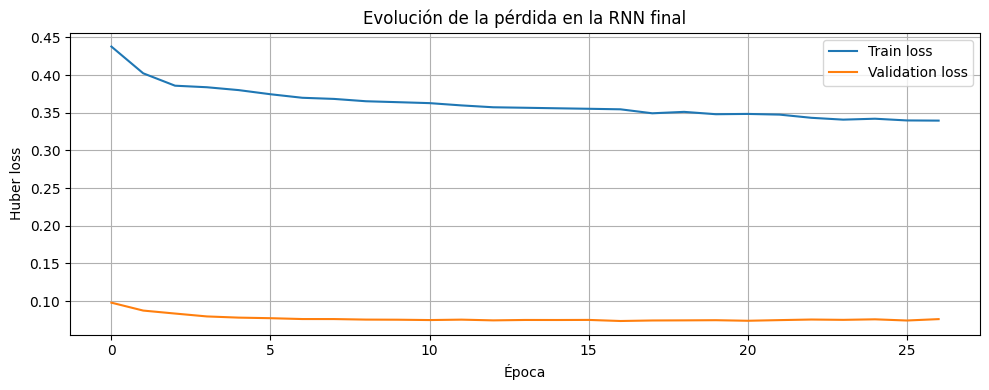

In [ ]:
# Crear una figura para representar la evolución de la pérdida
plt.figure(figsize=(10, 4))  # Tamaño de la figura

# Representar la pérdida de entrenamiento
plt.plot(history_rnn_final.history["loss"], label="Train loss")  # Curva de train

# Representar la pérdida de validación
plt.plot(history_rnn_final.history["val_loss"], label="Validation loss")  # Curva de validation

# Añadir título y etiquetas
plt.title("Evolución de la pérdida en la RNN final")
plt.xlabel("Época")
plt.ylabel("Huber loss")

# Añadir leyenda
plt.legend()

# Ajustar el diseño
plt.tight_layout()

# Mostrar figura
plt.show()

En este bloque se generan las predicciones del modelo final sobre el conjunto de validación y sobre el conjunto de test. Después se invierte el escalado para expresar tanto las predicciones como los valores reales en unidades originales de MWh. Esto permite calcular métricas interpretables y directamente comparables con el problema real. Es un paso esencial para pasar del espacio escalado de entrenamiento al análisis sustantivo de resultados.

In [ ]:
# Generar predicciones sobre validation
y_val_pred_scaled = modelo_rnn_final.predict(X_val_best, verbose=0)  # Predicciones escaladas en validation

# Generar predicciones sobre test
y_test_pred_scaled = modelo_rnn_final.predict(X_test_best, verbose=0)  # Predicciones escaladas en test

# Desescalar predicciones de validation
y_val_pred = scaler.inverse_transform(y_val_pred_scaled)  # Predicciones en MWh

# Desescalar predicciones de test
y_test_pred = scaler.inverse_transform(y_test_pred_scaled)  # Predicciones en MWh

# Desescalar valores reales de validation
y_val_real = scaler.inverse_transform(y_val_best)  # Valores reales en MWh

# Desescalar valores reales de test
y_test_real = scaler.inverse_transform(y_test_best)  # Valores reales en MWh

Aquí se calculan las métricas principales del modelo final sobre validación y test en la escala original de la serie. Se utiliza MAE como métrica principal y RMSE como complemento, lo que permite evaluar tanto el error medio absoluto como el peso de errores más grandes. Esta salida te servirá más adelante para redactar el apartado de resultados del modelo RNN en LaTeX. También te permitirá compararlo después con LSTM, GRU, BiLSTM, naïve y ARIMA.

In [ ]:
# Calcular MAE en validation
mae_val_final = mean_absolute_error(y_val_real, y_val_pred)  # Error absoluto medio en validation

# Calcular RMSE en validation
rmse_val_final = np.sqrt(mean_squared_error(y_val_real, y_val_pred))  # Error cuadrático medio en validation

# Calcular MAE en test
mae_test_final = mean_absolute_error(y_test_real, y_test_pred)  # Error absoluto medio en test

# Calcular RMSE en test
rmse_test_final = np.sqrt(mean_squared_error(y_test_real, y_test_pred))  # Error cuadrático medio en test

# Mostrar resultados
print("Resultados finales del modelo RNN")
print(f"MAE validation:  {mae_val_final:.3f} MWh")
print(f"RMSE validation: {rmse_val_final:.3f} MWh")
print(f"MAE test:        {mae_test_final:.3f} MWh")
print(f"RMSE test:       {rmse_test_final:.3f} MWh")

Resultados finales del modelo RNN
MAE validation:  6.126 MWh
RMSE validation: 7.786 MWh
MAE test:        5.997 MWh
RMSE test:       7.717 MWh


En esta última celda se representa gráficamente una parte de las predicciones del conjunto de test frente a los valores reales. Esta comparación visual permite evaluar de manera intuitiva hasta qué punto la RNN es capaz de seguir la forma general de la serie, capturar los cambios de nivel y aproximarse a la variabilidad observada.

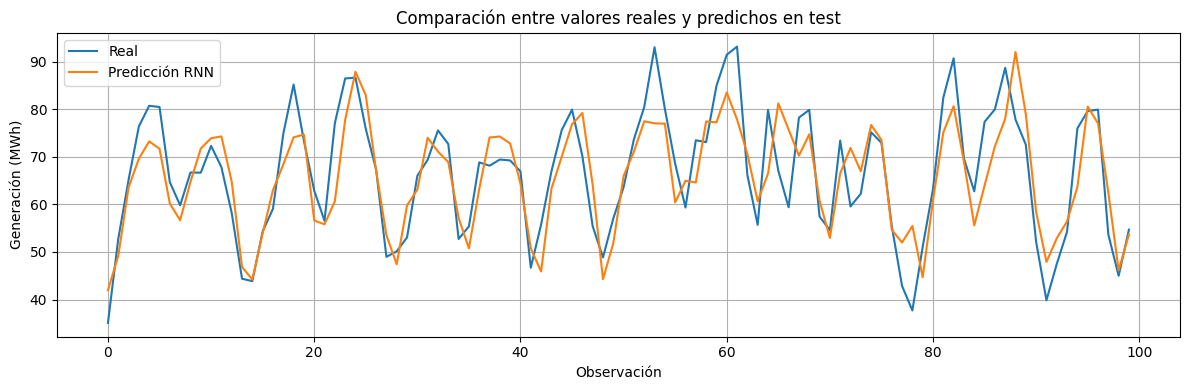

In [ ]:
# Definir cuántos puntos se van a mostrar en la gráfica
n_mostrar = 100  # Número de observaciones del test a representar

# Crear la figura
plt.figure(figsize=(12, 4))  # Tamaño de la figura

# Representar valores reales del test
plt.plot(y_test_real[:n_mostrar], label="Real")  # Serie observada

# Representar predicciones del test
plt.plot(y_test_pred[:n_mostrar], label="Predicción RNN")  # Serie predicha

# Añadir título y etiquetas
plt.title("Comparación entre valores reales y predichos en test")
plt.xlabel("Observación")
plt.ylabel("Generación (MWh)")

# Añadir leyenda
plt.legend()

# Ajustar el diseño
plt.tight_layout()

# Mostrar figura
plt.show()

Este bloque final construye una tabla resumen con las cinco mejores combinaciones de hiperparámetros obtenidas en la búsqueda aleatoria. La tabla permite ver de un vistazo qué configuraciones han ofrecido el mejor rendimiento y con qué métricas lo han hecho. Es especialmente útil para documentar la fase de selección del modelo y justificar por qué se ha escogido una configuración concreta. Esta salida la podrás reutilizar después directamente en el apartado metodológico o de resultados del TFG.

In [ ]:
# Crear una copia de la tabla top 5 para dejarla más limpia
tabla_top5_rnn = top5_rnn.copy()  # Copia independiente de la tabla ordenada

# Redondear métricas para facilitar la lectura
tabla_top5_rnn["val_mae"] = tabla_top5_rnn["val_mae"].round(3)      # Redondear MAE
tabla_top5_rnn["val_rmse"] = tabla_top5_rnn["val_rmse"].round(3)    # Redondear RMSE

# Renombrar columnas para que la tabla sea más clara
tabla_top5_rnn = tabla_top5_rnn.rename(columns={
    "window_size": "Window size",
    "units": "Units",
    "batch_size": "Batch size",
    "dropout": "Dropout",
    "epochs_trained": "Epochs trained",
    "val_mae": "Validation MAE",
    "val_rmse": "Validation RMSE"
})

# Mostrar la tabla final
print("Tabla resumen con las 5 mejores combinaciones de hiperparámetros para la RNN:\n")
print(tabla_top5_rnn)

# Si quieres verla con formato de DataFrame en Colab/Jupyter, deja esta línea al final
tabla_top5_rnn

Tabla resumen con las 5 mejores combinaciones de hiperparámetros para la RNN:

   Window size  Units  Batch size  Dropout  Epochs trained  Validation MAE  \
0           28     16          16      0.1              50           6.001   
1           21     16          32      0.0              24           6.088   
2           21      8           8      0.0              81           6.159   
3           21     32          16      0.0              19           6.224   
4           28      8           8      0.0              65           6.249   

   Validation RMSE  
0            7.699  
1            7.781  
2            7.840  
3            7.863  
4            7.894  


,Window size,Units,Batch size,Dropout,Epochs trained,Validation MAE,Validation RMSE
0,28,16,16,0.1,50,6.001,7.699
1,21,16,32,0.0,24,6.088,7.781
2,21,8,8,0.0,81,6.159,7.840
3,21,32,16,0.0,19,6.224,7.863
4,28,8,8,0.0,65,6.249,7.894


In [ ]:
# =========================
# PREDICCIONES TRAIN Y TEST
# =========================

# Generar predicciones sobre train
y_train_pred_scaled = modelo_rnn_final.predict(X_train_best, verbose=0)  # Predicciones en escala normalizada

# Generar predicciones sobre test
y_test_pred_scaled = modelo_rnn_final.predict(X_test_best, verbose=0)  # Predicciones en escala normalizada

# =========================
# DES-ESCALADO (VOLVER A MWh)
# =========================

# Convertir predicciones de train a valores reales
y_train_pred = scaler.inverse_transform(y_train_pred_scaled)

# Convertir predicciones de test a valores reales
y_test_pred = scaler.inverse_transform(y_test_pred_scaled)

# Convertir valores reales de train
y_train_real = scaler.inverse_transform(y_train_best)

# Convertir valores reales de test
y_test_real = scaler.inverse_transform(y_test_best)

# =========================
# CREAR EJES TEMPORALES
# =========================

# Crear eje temporal para train
train_time_steps = range(len(y_train_real))  # Desde 0 hasta tamaño de train

# Crear eje temporal para test (continuación de train)
test_time_steps = range(len(y_train_real), len(y_train_real) + len(y_test_real))  # Continuidad temporal

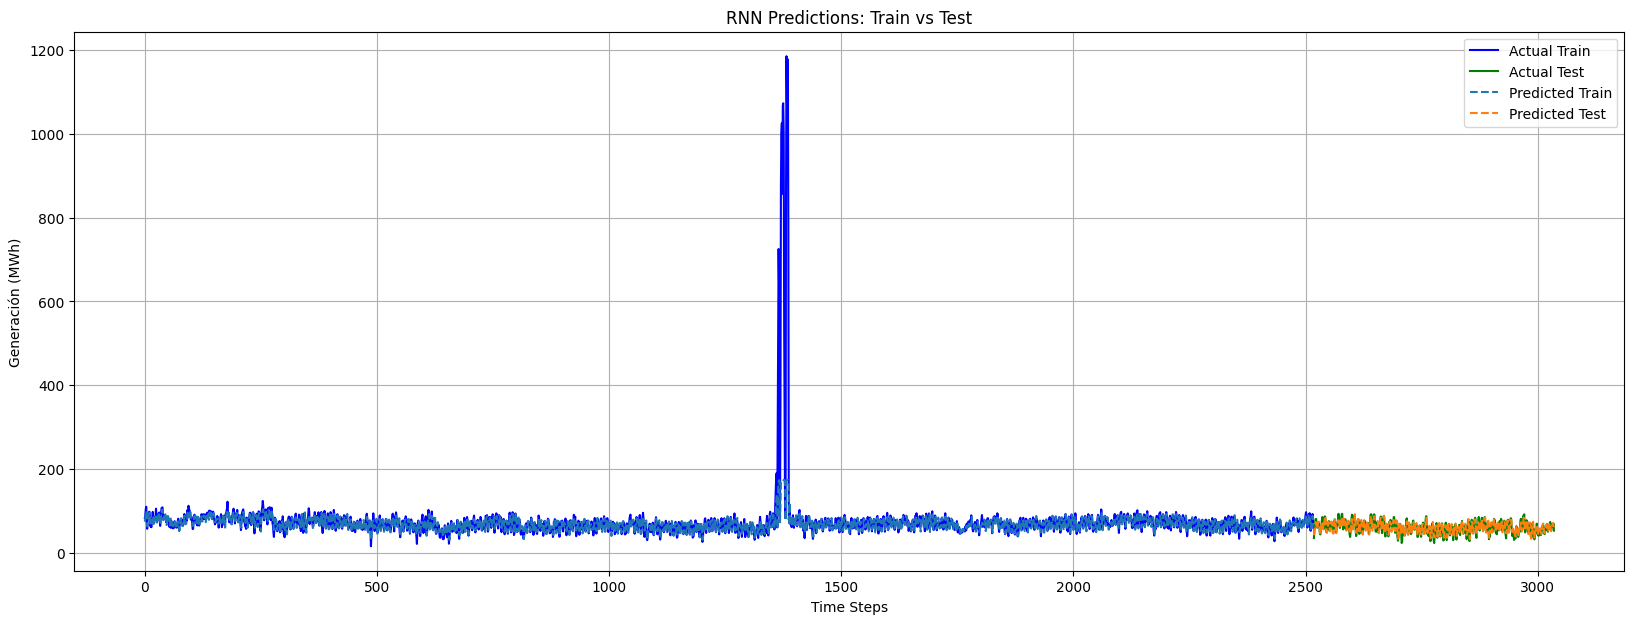

In [ ]:
# =========================
# GRAFICO FINAL RNN
# =========================

# Crear figura grande para mejor visualización
plt.figure(figsize=(20, 7))  # Tamaño grande para TFG

# =========================
# SERIES REALES
# =========================

# Serie real de entrenamiento
plt.plot(train_time_steps, y_train_real,
         label="Actual Train",
         color="blue")  # Línea azul continua

# Serie real de test
plt.plot(test_time_steps, y_test_real,
         label="Actual Test",
         color="green")  # Línea verde continua

# =========================
# SERIES PREDICHAS
# =========================

# Predicción en entrenamiento
plt.plot(train_time_steps, y_train_pred,
         label="Predicted Train",
         linestyle="--")  # Línea discontinua

# Predicción en test
plt.plot(test_time_steps, y_test_pred,
         label="Predicted Test",
         linestyle="--")  # Línea discontinua

# =========================
# PERSONALIZACION
# =========================

# Título del gráfico
plt.title("RNN Predictions: Train vs Test")

# Etiqueta eje X
plt.xlabel("Time Steps")

# Etiqueta eje Y
plt.ylabel("Generación (MWh)")

# Mostrar leyenda
plt.legend()

# Activar grid
plt.grid(True)

# Mostrar gráfico
plt.show()

**Cálculo de métricas en el conjunto de entrenamiento**

Para complementar el análisis del rendimiento del modelo dentro y fuera de muestra, se calculan también las métricas MAE y RMSE sobre el conjunto de entrenamiento. Se utilizan las predicciones ya generadas en bloques anteriores, que se encuentran desescaladas en MWh. Esto permite comparar de forma homogénea los errores en train, validation y test.

In [ ]:
# Calcular MAE en train
mae_train_final = mean_absolute_error(y_train_real, y_train_pred)  # Error absoluto medio en train

# Calcular RMSE en train
rmse_train_final = np.sqrt(mean_squared_error(y_train_real, y_train_pred))  # Raíz del error cuadrático medio en train

# Mostrar título de resultados
print("Métricas del modelo RNN en train")

# Mostrar MAE de train
print(f"MAE train:  {mae_train_final:.3f} MWh")

# Mostrar RMSE de train
print(f"RMSE train: {rmse_train_final:.3f} MWh")

Métricas del modelo RNN en train
MAE train:  11.694 MWh
RMSE train: 64.250 MWh


**Evolución del MAE en entrenamiento y validación**

Para completar el análisis del entrenamiento del modelo RNN final se representa la evolución del MAE a lo largo de las épocas, comparando el comportamiento del modelo en el conjunto de entrenamiento y en el de validación. A diferencia de la curva de pérdida Huber mostrada anteriormente, aquí el error se expresa directamente en MWh, lo que facilita su interpretación en el dominio de la generación eléctrica. Esta visualización permite valorar la velocidad de convergencia, la estabilidad del entrenamiento y la posible aparición de sobreajuste a través de la separación entre ambas curvas.

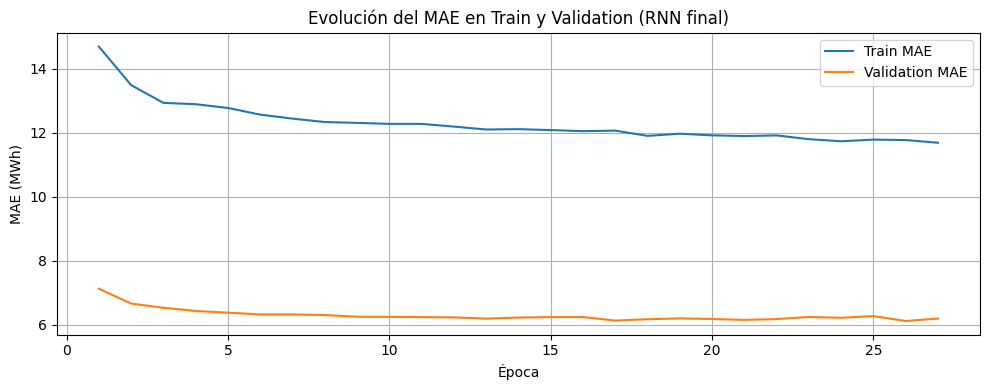

In [ ]:
# Recuperar el factor de escala del RobustScaler para expresar el MAE en MWh
iqr_factor = scaler.scale_[0]                                             # Factor de escala (IQR) usado por RobustScaler

# Convertir el MAE de train por época a la escala original (MWh)
train_mae_mwh = [m * iqr_factor for m in history_rnn_final.history["mae"]]      # MAE de train por época en MWh

# Convertir el MAE de validation por época a la escala original (MWh)
val_mae_mwh = [m * iqr_factor for m in history_rnn_final.history["val_mae"]]    # MAE de validación por época en MWh

# Construir un eje de épocas común
epochs_axis = range(1, len(train_mae_mwh) + 1)                            # Eje de épocas comenzando en 1

# Crear figura
plt.figure(figsize=(10, 4))                                               # Tamaño de la figura

# Representar la curva de MAE en entrenamiento
plt.plot(epochs_axis, train_mae_mwh, label="Train MAE")                   # Curva de MAE de train en MWh

# Representar la curva de MAE en validación
plt.plot(epochs_axis, val_mae_mwh, label="Validation MAE")                # Curva de MAE de validación en MWh

# Añadir título y etiquetas
plt.title("Evolución del MAE en Train y Validation (RNN final)")          # Título del gráfico
plt.xlabel("Época")                                                       # Etiqueta del eje X
plt.ylabel("MAE (MWh)")                                                   # Etiqueta del eje Y

# Añadir leyenda y ajustar diseño
plt.legend()                                                              # Mostrar leyenda
plt.tight_layout()                                                        # Ajustar márgenes automáticamente

# Mostrar figura
plt.show()                                                                # Renderizar gráfico